# 02 - E4 Preprocesamiento y normalizacion del dataset SPIDER

**Objetivo:** preparar el dataset SPIDER para una futura etapa de baseline de segmentacion sagital, sin entrenar todavia ningun modelo.

Este notebook cierra la etapa E4 de preprocesamiento, normalizacion, consistencia y preparacion de datos.

**Fuera de alcance:** entrenamiento, nnU-Net, MONAI y guardado masivo de todo el dataset preprocesado.

## 1. Instalacion e importacion de dependencias

In [1]:
!pip -q install SimpleITK scikit-image

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.1 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import json
import warnings

import SimpleITK as sitk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["image.cmap"] = "gray"

print("SimpleITK:", sitk.Version())
print("NumPy:", np.__version__)
print("pandas:", pd.__version__)

SimpleITK: SimpleITK Version: 2.5.5 (ITK 5.4)
Compiled: May 12 2026 17:19:38

NumPy: 2.0.2
pandas: 2.2.2


## 2. Montaje de Google Drive y definicion de rutas

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
DATASET_ROOT = Path("/content/drive/MyDrive/PFI_MVP/data/SPIDER")
IMAGES_ROOT = DATASET_ROOT / "images"
MASKS_ROOT = DATASET_ROOT / "masks"

RESULTS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento")
FIGURES_ROOT = Path("/content/drive/MyDrive/PFI_MVP/figures")
DOCS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/docs")

for path in [RESULTS_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT)
print("IMAGES_ROOT:", IMAGES_ROOT)
print("MASKS_ROOT:", MASKS_ROOT)
print("RESULTS_ROOT:", RESULTS_ROOT)
print("FIGURES_ROOT:", FIGURES_ROOT)
print("DOCS_ROOT:", DOCS_ROOT)

DATASET_ROOT: /content/drive/MyDrive/PFI_MVP/data/SPIDER
IMAGES_ROOT: /content/drive/MyDrive/PFI_MVP/data/SPIDER/images
MASKS_ROOT: /content/drive/MyDrive/PFI_MVP/data/SPIDER/masks
RESULTS_ROOT: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento
FIGURES_ROOT: /content/drive/MyDrive/PFI_MVP/figures
DOCS_ROOT: /content/drive/MyDrive/PFI_MVP/docs


## 3. Deteccion y emparejamiento de imagenes/mascaras

In [5]:
def find_mha_files(root: Path):
    return sorted(root.rglob("*.mha"))


image_paths = find_mha_files(IMAGES_ROOT)
mask_paths = find_mha_files(MASKS_ROOT)

image_by_name = {p.name: p for p in image_paths}
mask_by_name = {p.name: p for p in mask_paths}

image_names = set(image_by_name)
mask_names = set(mask_by_name)
paired_names = sorted(image_names & mask_names)
images_without_mask = sorted(image_names - mask_names)
masks_without_image = sorted(mask_names - image_names)

pair_rows = []
for name in paired_names:
    pair_rows.append({
        "case_id": Path(name).stem,
        "file_name": name,
        "image_path": str(image_by_name[name]),
        "mask_path": str(mask_by_name[name]),
        "pair_status": "paired",
    })

for name in images_without_mask:
    pair_rows.append({
        "case_id": Path(name).stem,
        "file_name": name,
        "image_path": str(image_by_name[name]),
        "mask_path": "",
        "pair_status": "image_without_mask",
    })

for name in masks_without_image:
    pair_rows.append({
        "case_id": Path(name).stem,
        "file_name": name,
        "image_path": "",
        "mask_path": str(mask_by_name[name]),
        "pair_status": "mask_without_image",
    })

pairs_df = pd.DataFrame(pair_rows)
pairs_csv_path = RESULTS_ROOT / "E4_spider_pairs.csv"
pairs_df.to_csv(pairs_csv_path, index=False)

pairs = [
    (Path(name).stem, image_by_name[name], mask_by_name[name])
    for name in paired_names
]

print(f"Imagenes .mha detectadas: {len(image_paths)}")
print(f"Mascaras .mha detectadas: {len(mask_paths)}")
print(f"Pares construidos por nombre de archivo: {len(pairs)}")
print(f"Imagenes sin mascara: {len(images_without_mask)}")
print(f"Mascaras sin imagen: {len(masks_without_image)}")
print("CSV de pares:", pairs_csv_path)

display(pairs_df.head())

Imagenes .mha detectadas: 447
Mascaras .mha detectadas: 447
Pares construidos por nombre de archivo: 447
Imagenes sin mascara: 0
Mascaras sin imagen: 0
CSV de pares: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_spider_pairs.csv


,case_id,file_name,image_path,mask_path,pair_status
0,100_t1,100_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,paired
1,100_t2,100_t2.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,paired
2,101_t1,101_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,paired
3,101_t2,101_t2.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,paired
4,104_t1,104_t1.mha,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,paired


## 4. Inspeccion de consistencia en multiples casos

In [11]:
def read_mha(path: Path):
    itk_image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(itk_image)  # NumPy: z, y, x
    return itk_image, array


def label_voxel_counts(mask_array):
    labels, counts = np.unique(mask_array, return_counts=True)
    return {
        str(label.item() if hasattr(label, "item") else label): int(count)
        for label, count in zip(labels, counts)
    }


def json_list(values):
    clean_values = []
    for value in values:
        clean_values.append(value.item() if hasattr(value, "item") else value)
    return json.dumps(clean_values)


def inspect_pair(case_id: str, image_path: Path, mask_path: Path):
    itk_img, image = read_mha(image_path)
    itk_mask, mask = read_mha(mask_path)

    percentiles = np.percentile(image.astype(np.float32), [1, 5, 50, 95, 99])
    labels = np.unique(mask)

    return {
        "case_id": case_id,
        "image_path": str(image_path),
        "mask_path": str(mask_path),
        "image_shape_zyx": str(tuple(int(x) for x in image.shape)),
        "mask_shape_zyx": str(tuple(int(x) for x in mask.shape)),
        "same_shape": tuple(image.shape) == tuple(mask.shape),
        "image_spacing_xyz": str(tuple(float(x) for x in itk_img.GetSpacing())),
        "mask_spacing_xyz": str(tuple(float(x) for x in itk_mask.GetSpacing())),
        "same_spacing": bool(np.allclose(itk_img.GetSpacing(), itk_mask.GetSpacing())),
        "image_origin_xyz": str(tuple(float(x) for x in itk_img.GetOrigin())),
        "mask_origin_xyz": str(tuple(float(x) for x in itk_mask.GetOrigin())),
        "same_origin": bool(np.allclose(itk_img.GetOrigin(), itk_mask.GetOrigin())),
        "image_direction": str(tuple(float(x) for x in itk_img.GetDirection())),
        "mask_direction": str(tuple(float(x) for x in itk_mask.GetDirection())),
        "same_direction": bool(np.allclose(itk_img.GetDirection(), itk_mask.GetDirection())),
        "image_dtype": str(image.dtype),
        "mask_dtype": str(mask.dtype),
        "image_min": float(np.min(image)),
        "image_max": float(np.max(image)),
        "image_mean": float(np.mean(image)),
        "image_p01": float(percentiles[0]),
        "image_p05": float(percentiles[1]),
        "image_p50": float(percentiles[2]),
        "image_p95": float(percentiles[3]),
        "image_p99": float(percentiles[4]),
        "mask_unique_labels": json_list(labels),
        "mask_label_voxel_counts": json.dumps(label_voxel_counts(mask)),
        "mask_nonzero_voxels": int(np.count_nonzero(mask)),
    }


consistency_rows = []
for case_id, image_path, mask_path in pairs:
    try:
        consistency_rows.append(inspect_pair(case_id, image_path, mask_path))
    except Exception as exc:
        consistency_rows.append({
            "case_id": case_id,
            "image_path": str(image_path),
            "mask_path": str(mask_path),
            "read_error": repr(exc),
        })

consistency_df = pd.DataFrame(consistency_rows)
consistency_csv_path = RESULTS_ROOT / "E4_spider_consistency_summary.csv"
consistency_df.to_csv(consistency_csv_path, index=False)

print("CSV de consistencia:", consistency_csv_path)
display(consistency_df.head())

CSV de consistencia: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_spider_consistency_summary.csv


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,...,image_max,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels
0,100_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(797, 492, 21)","(797, 492, 21)",True,"(4.389695960744017, 0.6305175528662943, 0.3879...","(4.389695960744017, 0.6305175528662943, 0.3879...",True,"(-44.77723154001997, -122.57786786661, -106.77...",...,3096.0,323.473495,-1000.0,-1000.0,119.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 7882170, ""1"": 39628, ""2"": 41281, ""3"": 39...",352434
1,100_t2,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(797, 492, 21)","(797, 492, 21)",True,"(4.389695960744017, 0.6305175528662943, 0.3879...","(4.389695960744017, 0.6305175528662943, 0.3879...",True,"(-44.77723154001997, -122.57786786661, -106.77...",...,3096.0,284.090210,-1000.0,-1000.0,-206.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 7882170, ""1"": 39628, ""2"": 41281, ""3"": 39...",352434
2,101_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(298, 320, 17)","(298, 320, 17)",True,"(4.788765599257572, 0.812500000003979, 0.87628...","(4.788765599257572, 0.812500000003979, 0.87628...",True,"(-67.28904018297013, -124.77837801043, -103.82...",...,3096.0,286.182632,-1000.0,-1000.0,-96.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 1485954, ""1"": 17797, ""2"": 19492, ""3"": 18...",135166
3,101_t2,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(352, 384, 17)","(352, 384, 17)",True,"(4.7905672101450465, 0.6770833134684295, 0.740...","(4.7905672101450465, 0.6770833134684295, 0.740...",True,"(-67.28904013221916, -124.77837419574, -103.95...",...,3096.0,96.152873,-1000.0,-1000.0,-451.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 2106060, ""1"": 25305, ""2"": 27649, ""3"": 26...",191796
4,104_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(320, 320, 15)","(320, 320, 15)",True,"(4.8000000544956425, 0.875, 0.875)","(4.8000000544956425, 0.875, 0.875)",True,"(-1500.868783405839, -123.65617370674, -102.07...",...,3096.0,416.166051,-1000.0,-1000.0,86.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 1424313, ""1"": 13002, ""2"": 13903, ""3"": 14...",111687


In [12]:
if len(consistency_df) == 0:
    raise RuntimeError("No se encontraron pares imagen/mascara para inspeccionar.")

check_columns = ["same_shape", "same_spacing", "same_origin", "same_direction"]
checks = {
    "total_pairs": int(len(consistency_df)),
    "read_error_cases": int(consistency_df["read_error"].notna().sum()) if "read_error" in consistency_df else 0,
}
for column in check_columns:
    if column in consistency_df:
        checks[column + "_ok"] = int(consistency_df[column].fillna(False).sum())
        checks[column + "_fail"] = int((consistency_df[column].fillna(False) == False).sum())

display(pd.DataFrame([checks]))

inconsistent_mask = pd.Series(False, index=consistency_df.index)
for column in check_columns:
    if column in consistency_df:
        inconsistent_mask = inconsistent_mask | (consistency_df[column].fillna(False) == False)

inconsistent_df = consistency_df[inconsistent_mask]
print("Casos con inconsistencias geometricas relevantes:", len(inconsistent_df))
display(inconsistent_df.head(20))

,total_pairs,read_error_cases,same_shape_ok,same_shape_fail,same_spacing_ok,same_spacing_fail,same_origin_ok,same_origin_fail,same_direction_ok,same_direction_fail
0,447,0,447,0,447,0,447,0,433,14


Casos con inconsistencias geometricas relevantes: 14


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,...,image_max,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels
21,110_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(38.684417724609375, -117.8208236694336, 416.9...",...,433.0,41.805106,0.0,1.0,16.0,154.0,216.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 37060511, ""1"": 279613, ""2"": 267092, ""3"":...",2261089
111,162_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(44.65591049194336, -131.92770385742188, 273.6...",...,520.0,65.148541,0.0,5.0,25.0,244.0,302.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 37542719, ""1"": 132505, ""2"": 153393, ""3"":...",1778881
118,166_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(47.28323745727539, -125.44794464111328, 232.7...",...,521.0,43.414645,0.0,2.0,18.0,174.0,255.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 37231433, ""1"": 222637, ""2"": 238591, ""3"":...",2090167
141,177_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(61.9112663269043, -114.55205535888672, 273.73...",...,487.0,61.572643,0.0,1.0,21.0,239.0,298.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 100, 201, 202, ...","{""0"": 37536998, ""1"": 209052, ""2"": 194727, ""3"":...",1784602
156,185_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(81.08792114257812, -113.45223999023438, 210.8...",...,475.0,43.501536,0.0,0.0,14.0,178.0,246.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 37210088, ""1"": 247979, ""2"": 265704, ""3"":...",2111512
167,18_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(88.24879455566406, -114.68063354492188, 218.1...",...,514.0,42.570449,0.0,1.0,15.0,165.0,263.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 37317490, ""1"": 197422, ""2"": 213834, ""3"":...",2004110
225,220_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(53.77259826660156, -123.25301361083984, 236.0...",...,475.0,60.288652,0.0,3.0,23.0,216.0,268.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 37295941, ""1"": 206268, ""2"": 214262, ""3"":...",2025659
246,22_t2_SPACE,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(120, 640, 512)","(120, 640, 512)",True,"(0.46875, 0.46875, 0.8999999761581421)","(0.46875, 0.46875, 0.8999999761581421)",True,"(60.73966979980469, -121.08433532714844, 212.1...",...,480.0,72.616558,0.0,2.0,34.0,241.0,276.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 37820037, ""1"": 140127, ""2"": 148835, ""3"":...",1501563
255,234_t2_SPACE,/content/drive/

## 5. Normalizacion robusta de intensidades

In [13]:
def robust_percentile_normalize(image_array, p_low=1, p_high=99, eps=1e-8):
    image_float = image_array.astype(np.float32)
    low, high = np.percentile(image_float, [p_low, p_high])

    clipped = np.clip(image_float, low, high)
    if np.isclose(high, low):
        normalized = np.zeros_like(clipped, dtype=np.float32)
    else:
        normalized = (clipped - low) / (high - low + eps)

    metadata = {
        "method": "percentile_clip_scale_0_1",
        "p_low": float(p_low),
        "p_high": float(p_high),
        "value_low": float(low),
        "value_high": float(high),
    }
    return normalized.astype(np.float32), metadata


example_case_id, example_image_path, example_mask_path = pairs[0]
example_itk, example_image = read_mha(example_image_path)
example_mask_itk, example_mask = read_mha(example_mask_path)

mask_before = example_mask.copy()
example_image_norm, normalization_metadata = robust_percentile_normalize(example_image)

print("Caso de ejemplo:", example_case_id)
print("Imagen original:", example_image.shape, example_image.dtype, float(example_image.min()), float(example_image.max()))
print("Imagen normalizada:", example_image_norm.shape, example_image_norm.dtype, float(example_image_norm.min()), float(example_image_norm.max()))
print("Mascara sin modificar:", bool(np.array_equal(example_mask, mask_before)))
print("Labels de mascara:", np.unique(example_mask))
print("Normalizacion:", normalization_metadata)

Caso de ejemplo: 100_t1
Imagen original: (797, 492, 21) int16 -1000.0 3096.0
Imagen normalizada: (797, 492, 21) float32 0.0 1.0
Mascara sin modificar: True
Labels de mascara: [  0   1   2   3   4   5   6   7   8 100 201 202 203 204 205 206 207 208]
Normalizacion: {'method': 'percentile_clip_scale_0_1', 'p_low': 1.0, 'p_high': 99.0, 'value_low': -1000.0, 'value_high': 3096.0}


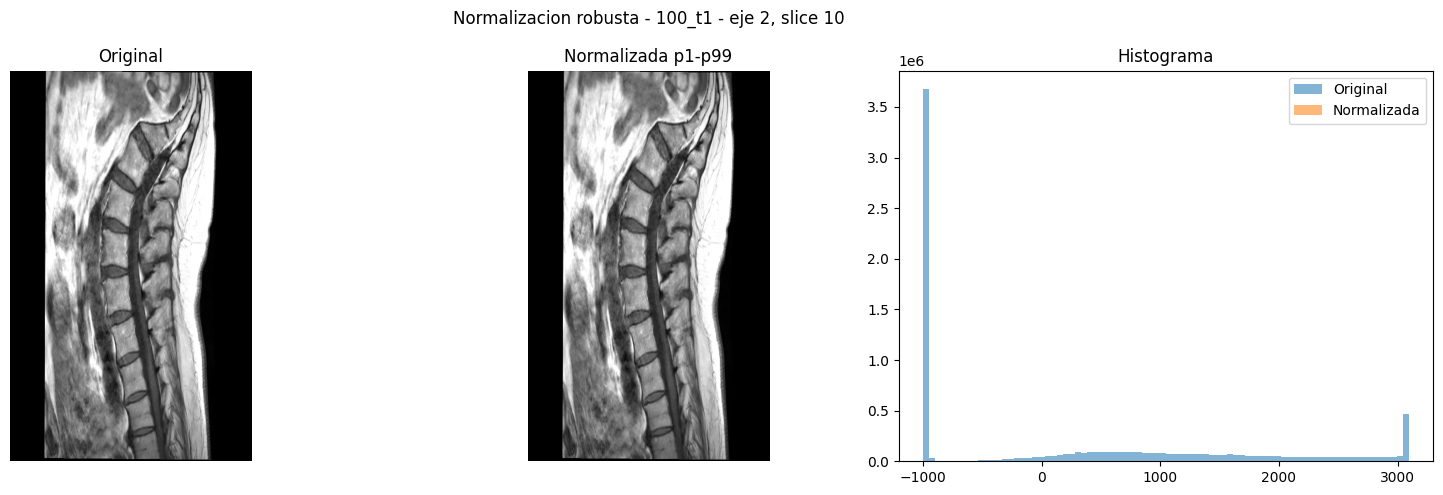

PNG antes/despues: /content/drive/MyDrive/PFI_MVP/figures/E4_normalizacion_antes_despues_100_t1.png


In [14]:
def representative_slice_index(mask_array, axis):
    if mask_array is not None and np.count_nonzero(mask_array) > 0:
        reduce_axes = tuple(ax for ax in range(mask_array.ndim) if ax != axis)
        mask_area_by_slice = np.sum(mask_array > 0, axis=reduce_axes)
        return int(np.argmax(mask_area_by_slice))
    return None


def take_slice(array, axis, index):
    return np.take(array, indices=index, axis=axis)


SAGITTAL_AXIS = 2
example_slice_index = representative_slice_index(example_mask, axis=SAGITTAL_AXIS)
if example_slice_index is None:
    example_slice_index = example_image.shape[SAGITTAL_AXIS] // 2

original_slice = take_slice(example_image, SAGITTAL_AXIS, example_slice_index)
normalized_slice = take_slice(example_image_norm, SAGITTAL_AXIS, example_slice_index)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].imshow(original_slice, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")
axes[1].imshow(normalized_slice, cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Normalizada p1-p99")
axes[1].axis("off")
axes[2].hist(example_image.ravel(), bins=80, alpha=0.55, label="Original")
axes[2].hist(example_image_norm.ravel(), bins=80, alpha=0.55, label="Normalizada")
axes[2].set_title("Histograma")
axes[2].legend()
fig.suptitle(f"Normalizacion robusta - {example_case_id} - eje {SAGITTAL_AXIS}, slice {example_slice_index}")
fig.tight_layout()

normalization_png_path = FIGURES_ROOT / f"E4_normalizacion_antes_despues_{example_case_id}.png"
fig.savefig(normalization_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("PNG antes/despues:", normalization_png_path)

## 6. Confirmacion de eje sagital

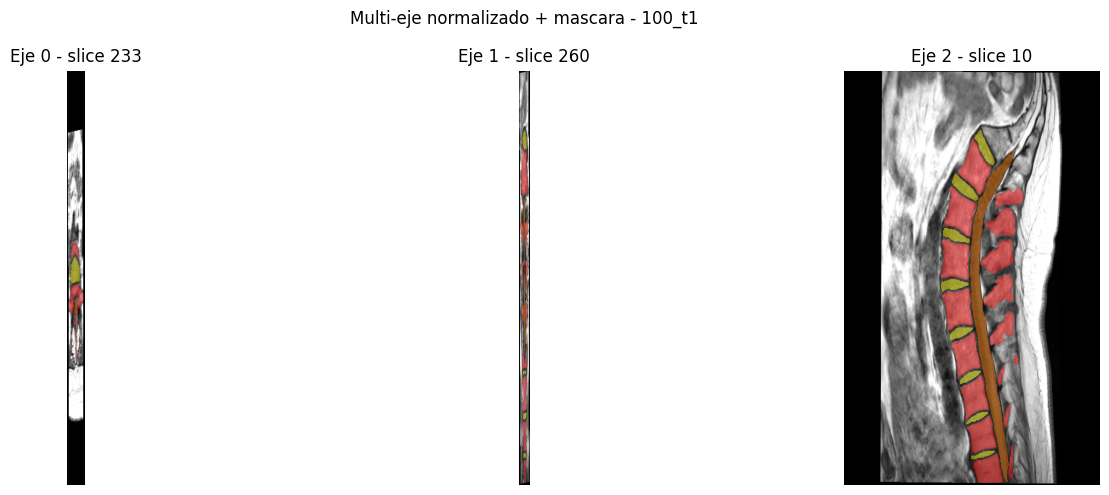

Slices seleccionados automaticamente por mayor area de mascara: {0: 233, 1: 260, 2: 10}
Eje confirmado visualmente como vista sagital representativa en este caso: 2
Nota: esta eleccion debe revisarse en mas casos antes de fijarla para el baseline final.
PNG multi-eje: /content/drive/MyDrive/PFI_MVP/figures/E4_multieje_normalizado_100_t1.png


In [15]:
def plot_multi_axis(image_array, mask_array, case_id):
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    selected_slices = {}

    for axis in range(3):
        slice_index = representative_slice_index(mask_array, axis=axis)
        if slice_index is None:
            slice_index = image_array.shape[axis] // 2
        selected_slices[axis] = int(slice_index)

        image_slice = take_slice(image_array, axis, slice_index)
        mask_slice = take_slice(mask_array, axis, slice_index)

        axes[axis].imshow(image_slice, cmap="gray", vmin=0, vmax=1)
        axes[axis].imshow(np.ma.masked_where(mask_slice == 0, mask_slice), cmap="autumn", alpha=0.45)
        axes[axis].set_title(f"Eje {axis} - slice {slice_index}")
        axes[axis].axis("off")

    fig.suptitle(f"Multi-eje normalizado + mascara - {case_id}")
    fig.tight_layout()
    return fig, selected_slices


multi_axis_fig, selected_slices = plot_multi_axis(example_image_norm, example_mask, example_case_id)
multi_axis_png_path = FIGURES_ROOT / f"E4_multieje_normalizado_{example_case_id}.png"
multi_axis_fig.savefig(multi_axis_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("Slices seleccionados automaticamente por mayor area de mascara:", selected_slices)
print("Eje confirmado visualmente como vista sagital representativa en este caso:", SAGITTAL_AXIS)
print("Nota: esta eleccion debe revisarse en mas casos antes de fijarla para el baseline final.")
print("PNG multi-eje:", multi_axis_png_path)

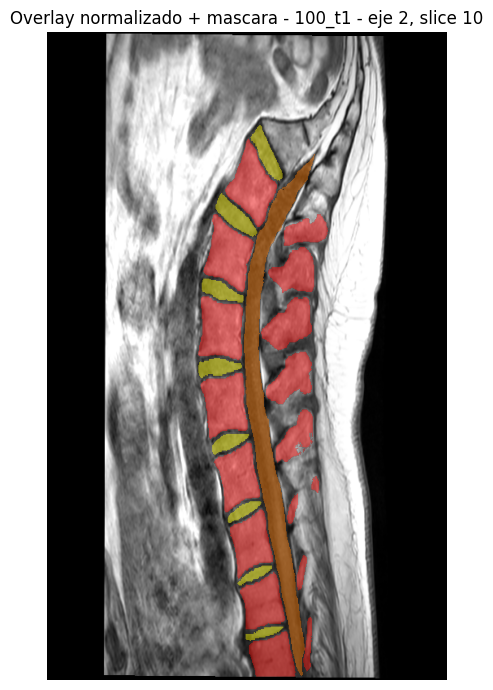

PNG overlay normalizado + mascara: /content/drive/MyDrive/PFI_MVP/figures/E4_overlay_normalizado_mascara_100_t1.png


In [16]:
def plot_normalized_overlay(image_array, mask_array, axis, slice_index, case_id):
    image_slice = take_slice(image_array, axis, slice_index)
    mask_slice = take_slice(mask_array, axis, slice_index)

    fig, ax = plt.subplots(1, 1, figsize=(7, 7))
    ax.imshow(image_slice, cmap="gray", vmin=0, vmax=1)
    ax.imshow(np.ma.masked_where(mask_slice == 0, mask_slice), cmap="autumn", alpha=0.45)
    ax.set_title(f"Overlay normalizado + mascara - {case_id} - eje {axis}, slice {slice_index}")
    ax.axis("off")
    fig.tight_layout()
    return fig


overlay_fig = plot_normalized_overlay(
    example_image_norm,
    example_mask,
    axis=SAGITTAL_AXIS,
    slice_index=example_slice_index,
    case_id=example_case_id,
)
overlay_png_path = FIGURES_ROOT / f"E4_overlay_normalizado_mascara_{example_case_id}.png"
overlay_fig.savefig(overlay_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("PNG overlay normalizado + mascara:", overlay_png_path)

## 7. Preparacion de caso para baseline sagital

In [17]:
def prepare_case_for_sagittal_baseline(image_path: Path, mask_path: Path, axis=2):
    itk_img, image = read_mha(image_path)
    itk_mask, mask = read_mha(mask_path)

    if image.shape != mask.shape:
        raise ValueError(f"Shape incompatible: image={image.shape}, mask={mask.shape}")

    if not np.allclose(itk_img.GetSpacing(), itk_mask.GetSpacing()):
        raise ValueError(f"Spacing incompatible: image={itk_img.GetSpacing()}, mask={itk_mask.GetSpacing()}")

    normalized, norm_metadata = robust_percentile_normalize(image)
    slice_index = representative_slice_index(mask, axis=axis)
    if slice_index is None:
        slice_index = normalized.shape[axis] // 2

    metadata = {
        "case_id": image_path.stem,
        "shape_zyx": tuple(int(x) for x in image.shape),
        "spacing_xyz": tuple(float(x) for x in itk_img.GetSpacing()),
        "origin_xyz": tuple(float(x) for x in itk_img.GetOrigin()),
        "direction": tuple(float(x) for x in itk_img.GetDirection()),
        "axis": int(axis),
        "slice_index": int(slice_index),
        "normalization": norm_metadata,
    }

    return {
        "image": normalized,
        "mask": mask,
        "image_slice": take_slice(normalized, axis, slice_index),
        "mask_slice": take_slice(mask, axis, slice_index),
        "metadata": metadata,
        "spacing": np.array(itk_img.GetSpacing(), dtype=np.float32),
        "source_image_path": str(image_path),
        "source_mask_path": str(mask_path),
    }


prepared_case = prepare_case_for_sagittal_baseline(example_image_path, example_mask_path, axis=SAGITTAL_AXIS)

print("Caso preparado:", prepared_case["metadata"]["case_id"])
print("image:", prepared_case["image"].shape, prepared_case["image"].dtype)
print("mask:", prepared_case["mask"].shape, prepared_case["mask"].dtype)
print("image_slice:", prepared_case["image_slice"].shape)
print("mask_slice:", prepared_case["mask_slice"].shape)
prepared_case["metadata"]

Caso preparado: 100_t1
image: (797, 492, 21) float32
mask: (797, 492, 21) int16
image_slice: (797, 492)
mask_slice: (797, 492)


{'case_id': '100_t1',
 'shape_zyx': (797, 492, 21),
 'spacing_xyz': (4.389695960744017, 0.6305175528662943, 0.38792314385787563),
 'origin_xyz': (-44.77723154001997, -122.57786786661, -106.77207503644567),
 'direction': (1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0),
 'axis': 2,
 'slice_index': 10,
 'normalization': {'method': 'percentile_clip_scale_0_1',
  'p_low': 1.0,
  'p_high': 99.0,
  'value_low': -1000.0,
  'value_high': 3096.0}}

In [18]:
npz_path = RESULTS_ROOT / f"E4_preprocessed_example_{prepared_case['metadata']['case_id']}.npz"

np.savez_compressed(
    npz_path,
    image=prepared_case["image"],
    mask=prepared_case["mask"],
    image_slice=prepared_case["image_slice"],
    mask_slice=prepared_case["mask_slice"],
    spacing=prepared_case["spacing"],
    source_image_path=np.array(prepared_case["source_image_path"]),
    source_mask_path=np.array(prepared_case["source_mask_path"]),
    metadata=np.array(json.dumps(prepared_case["metadata"])),
)

print("Archivo .npz exportado:", npz_path)
print("Claves esperadas: image, mask, image_slice, mask_slice, spacing, source_image_path, source_mask_path")

Archivo .npz exportado: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_preprocessed_example_100_t1.npz
Claves esperadas: image, mask, image_slice, mask_slice, spacing, source_image_path, source_mask_path


## 8. Evidencias y conclusion tecnica

In [19]:
conclusion_md = f"""# Conclusion tecnica - E4 Preprocesamiento y normalizacion SPIDER

## Objetivo

Se preparo el dataset SPIDER para una futura etapa de baseline de segmentacion sagital, sin entrenamiento, sin nnU-Net y sin MONAI.

## Resultados principales

- Imagenes `.mha` detectadas: {len(image_paths)}
- Mascaras `.mha` detectadas: {len(mask_paths)}
- Pares imagen/mascara construidos por nombre de archivo: {len(pairs)}
- Imagenes sin mascara: {len(images_without_mask)}
- Mascaras sin imagen: {len(masks_without_image)}
- Caso de ejemplo preparado: `{example_case_id}`
- Eje usado para vista sagital representativa en el caso de ejemplo: eje {SAGITTAL_AXIS}

## Normalizacion

Se implemento una normalizacion robusta por percentiles p1-p99. El procedimiento recorta valores extremos y escala la imagen al rango `[0, 1]`. La mascara se conserva sin modificaciones para no alterar sus labels.

## Evidencias exportadas

- Pares detectados: `{pairs_csv_path}`
- Consistencia del dataset: `{consistency_csv_path}`
- Comparacion antes/despues de normalizacion: `{normalization_png_path}`
- Overlay normalizado + mascara: `{overlay_png_path}`
- Multi-eje normalizado: `{multi_axis_png_path}`
- Caso de prueba `.npz`: `{npz_path}`

## Criterio de aceptacion

El notebook permite emparejar imagenes y mascaras, detectar inconsistencias relevantes, normalizar una imagen sin alterar la mascara, confirmar un eje de trabajo para vista sagital, exportar evidencia reproducible y dejar un caso preparado para el notebook posterior de baseline sagital.

## Nota de orientacion

El eje 2 se confirma visualmente como vista sagital representativa en el caso evaluado. Esta eleccion debe verificarse en mas casos antes de congelarla definitivamente para el baseline.
"""

conclusion_md_path = DOCS_ROOT / "E4_preprocesamiento_normalizacion_conclusion.md"
conclusion_md_path.write_text(conclusion_md, encoding="utf-8")

print(conclusion_md)
print("Conclusion Markdown:", conclusion_md_path)

# Conclusion tecnica - E4 Preprocesamiento y normalizacion SPIDER

## Objetivo

Se preparo el dataset SPIDER para una futura etapa de baseline de segmentacion sagital, sin entrenamiento, sin nnU-Net y sin MONAI.

## Resultados principales

- Imagenes `.mha` detectadas: 447
- Mascaras `.mha` detectadas: 447
- Pares imagen/mascara construidos por nombre de archivo: 447
- Imagenes sin mascara: 0
- Mascaras sin imagen: 0
- Caso de ejemplo preparado: `100_t1`
- Eje usado para vista sagital representativa en el caso de ejemplo: eje 2

## Normalizacion

Se implemento una normalizacion robusta por percentiles p1-p99. El procedimiento recorta valores extremos y escala la imagen al rango `[0, 1]`. La mascara se conserva sin modificaciones para no alterar sus labels.

## Evidencias exportadas

- Pares detectados: `/content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_spider_pairs.csv`
- Consistencia del dataset: `/content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_spider_consist

## 9. Cierre de E4

Este notebook queda limitado a preprocesamiento, normalizacion, consistencia y preparacion de un caso de prueba.

No entrena modelos, no ejecuta nnU-Net y no introduce MONAI.

In [22]:
baseline_candidates = consistency_df[
    (consistency_df["same_shape"] == True) &
    (consistency_df["same_spacing"] == True) &
    (consistency_df["same_origin"] == True) &
    (consistency_df["same_direction"] == True) &
    (~consistency_df["case_id"].str.contains("SPACE", case=False, na=False))
].copy()

print("Candidatos recomendados para baseline inicial:", len(baseline_candidates))
display(baseline_candidates[["case_id", "image_shape_zyx", "image_spacing_xyz", "mask_unique_labels"]].head(20))

baseline_candidates_path = PREPROCESS_ROOT / "E4_baseline_candidates_no_space.csv"
baseline_candidates.to_csv(baseline_candidates_path, index=False)

print("CSV candidatos baseline:", baseline_candidates_path)

Candidatos recomendados para baseline inicial: 406


,case_id,image_shape_zyx,image_spacing_xyz,mask_unique_labels
0,100_t1,"(797, 492, 21)","(4.389695960744017, 0.6305175528662943, 0.3879...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203..."
1,100_t2,"(797, 492, 21)","(4.389695960744017, 0.6305175528662943, 0.3879...","[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203..."
2,101_t1,"(298, 320, 17)","(4.788765599257572, 0.812500000003979, 0.87628...","[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,..."
3,101_t2,"(352, 384, 17)","(4.7905672101450465, 0.6770833134684295, 0.740...","[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,..."
4,104_t1,"(320, 320, 15)","(4.8000000544956425, 0.875, 0.875)","[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2..."
5,104_t2,"(384, 384, 15)","(4.8000000544956425, 0.72916668653488, 0.72916...","[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2..."
6,105_t1,"(427, 448, 25)","(3.2936790151942077, 0.625, 0.6574980457806419)","[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2..."
7,105_t2,"(427, 448, 25)","(3.2936790151942077, 0.625, 0.6574980457806419)","[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2..."
8,106_t1,"(384, 384, 15)","(4.399999891008642, 0.72916668653488, 0.729166...","[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2..."
9,106_t2,"(384, 384, 15)","(4.399999891008642, 0.72916668653488, 0.729166...","[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2..."


CSV candidatos baseline: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_baseline_candidates_no_space.csv
